# Exploratory Data Analysis & Quality Audit
**Author:** Bart Teeuwen  
**Course:** Capstone Project  
**Framework Standard:** APA 7th Edition  

---

## Abstract
This module performs physical telemetry audits, checks for zero-missingness, filters invalid SDC velocity values ($> 38\text{ m/s}$), and maps agent distributions.

**Section 2: Exploratory Data Analysis (EDA)**

--- 1. Missing Values Assessment ---
Result: 0% missing values across all features.
Explanation: Waymo's native hardware flags handled dropouts during streaming. No imputation required.

--- 2. Raw Data Spread & Summary Statistics ---
Notice the massive gap between the '50%' (Median) and the 'max' values for agents.


,max_velocity_mps,pedestrian_count,vehicle_count,lane_count,stop_sign_count,crosswalk_count
count,6949.00,6949.00,6949.00,6949.00,6949.00,6949.00
mean,25.30,11.74,84.96,213.34,3.49,7.57
std,13.58,23.27,60.05,147.67,3.60,4.89
min,1.87,0.00,1.00,4.00,0.00,0.00
25%,18.23,1.00,42.00,102.00,1.00,4.00
50%,22.25,5.00,71.00,173.00,3.00,7.00
75%,27.25,12.00,112.00,288.00,5.00,10.00
max,127.34,426.00,736.00,1054.00,44.00,41.00



--- 3. Tracking Anomalies (The 100mph Filter) ---
Total Raw Scenarios Ingested: 6949
Anomalies Flagged (>38.0 m/s): 638
Maximum Glitch Speed Recorded: 127.34 m/s (Unphysical artifact)

--- 4. Visualizing Anomalies & Skewness ---


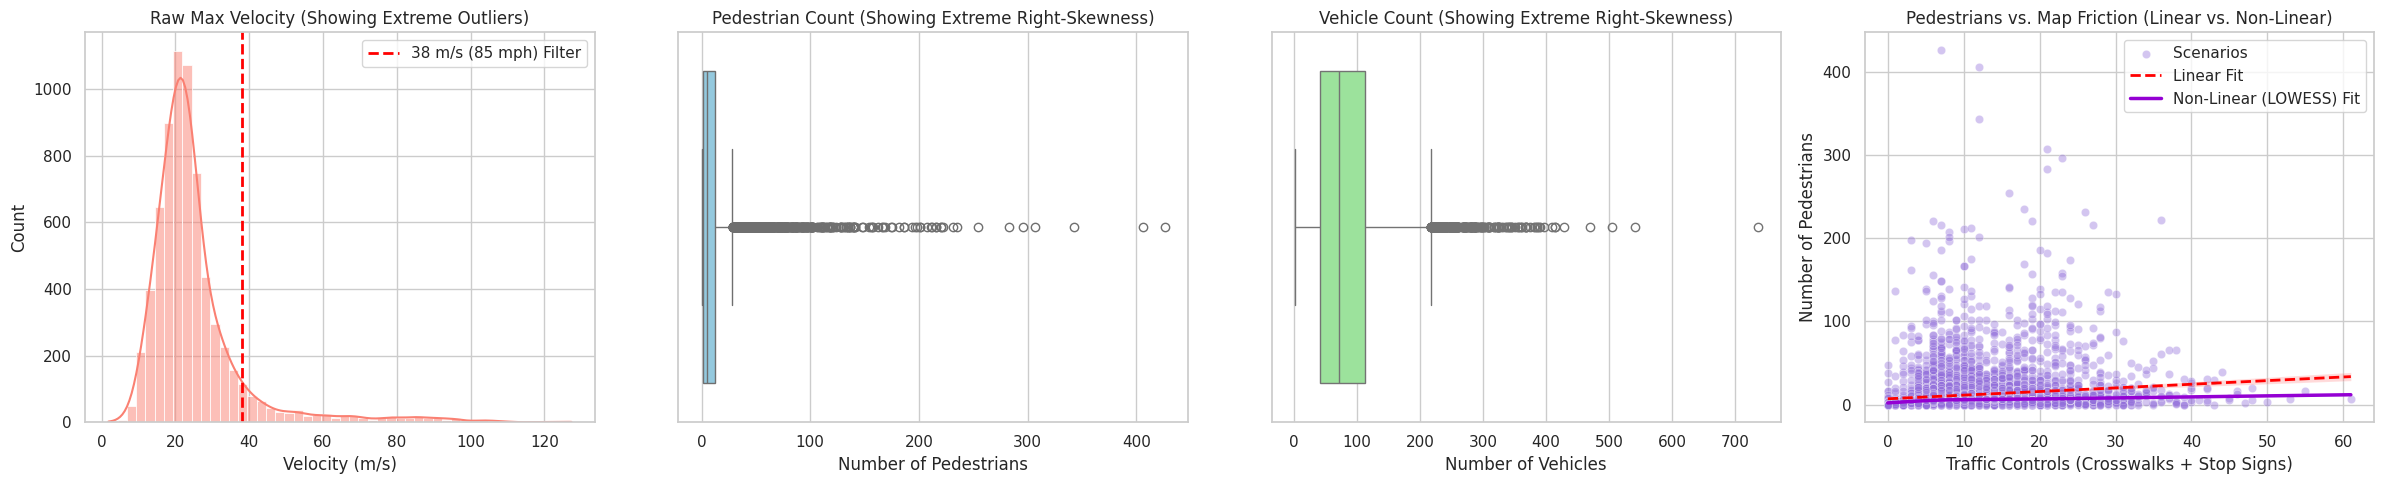

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

# Load data
df_raw = pd.DataFrame(raw_extracted_scenes)

# Check for missingness
print("--- 1. Missing Values Assessment ---")
missing_data = df_raw.isnull().sum()
if missing_data.sum() == 0:
    print("Result: 0% missing values across all features.")
    print("Explanation: Waymo's native hardware flags handled dropouts during streaming. No imputation required.\n")
else:
    print(missing_data[missing_data > 0])

# Summary statistics
print("--- 2. Raw Data Spread & Summary Statistics ---")
print("Notice the massive gap between the '50%' (Median) and the 'max' values for agents.")
raw_stats = df_raw[['max_velocity_mps', 'pedestrian_count', 'vehicle_count',
                    'lane_count', 'stop_sign_count', 'crosswalk_count']].describe().round(2)
display(raw_stats) # Renders a nice HTML table in Google Colab

# Check for anomalies
print("\n--- 3. Tracking Anomalies (The 100mph Filter) ---")
anomalies = df_raw[df_raw['is_valid_physics'] == False]
print(f"Total Raw Scenarios Ingested: {len(df_raw)}")
print(f"Anomalies Flagged (>38.0 m/s): {len(anomalies)}")
if len(anomalies) > 0:
    print(f"Maximum Glitch Speed Recorded: {anomalies['max_velocity_mps'].max()} m/s (Unphysical artifact)")

# Plotting results
print("\n--- 4. Visualizing Anomalies & Skewness ---")
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Plot 1: Velocity Distribution & The Physical Filter Line (Updated to 38 m/s)
sns.histplot(df_raw['max_velocity_mps'], bins=50, ax=axes[0], color='salmon', kde=True)
axes[0].axvline(x=38.0, color='red', linestyle='--', linewidth=2, label='38 m/s (85 mph) Filter')
axes[0].set_title('Raw Max Velocity (Showing Extreme Outliers)')
axes[0].set_xlabel('Velocity (m/s)')
axes[0].legend()

# Plot 2: Pedestrian Skewness (Boxplot)
sns.boxplot(x=df_raw['pedestrian_count'], ax=axes[1], color='skyblue')
axes[1].set_title('Pedestrian Count (Showing Extreme Right-Skewness)')
axes[1].set_xlabel('Number of Pedestrians')

# Plot 3: Vehicle Skewness (Boxplot)
sns.boxplot(x=df_raw['vehicle_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Vehicle Count (Showing Extreme Right-Skewness)')
axes[2].set_xlabel('Number of Vehicles')

# ---> UPDATED PLOT 4: Linear vs. Non-Linear Trendlines <---
traffic_controls = df_raw['crosswalk_count'] + df_raw['stop_sign_count']

# 1. Scatter Points
sns.scatterplot(
    x=traffic_controls,
    y=df_raw['pedestrian_count'],
    ax=axes[3],
    color='mediumpurple',
    alpha=0.4,
    label='Scenarios'
)

# 2. Linear Regression Line (Dashed Red Line)
sns.regplot(
    x=traffic_controls,
    y=df_raw['pedestrian_count'],
    ax=axes[3],
    scatter=False,
    color='red',
    line_kws={'linestyle': '--', 'linewidth': 2},
    label='Linear Fit'
)

# 3. Non-Linear LOWESS Line (Solid Dark Purple Curve)
sns.regplot(
    x=traffic_controls,
    y=df_raw['pedestrian_count'],
    ax=axes[3],
    scatter=False,
    lowess=True,
    color='darkviolet',
    line_kws={'linewidth': 2.5},
    label='Non-Linear (LOWESS) Fit'
)

axes[3].set_title('Pedestrians vs. Map Friction (Linear vs. Non-Linear)')
axes[3].set_xlabel('Traffic Controls (Crosswalks + Stop Signs)')
axes[3].set_ylabel('Number of Pedestrians')
axes[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Search all DataFrames currently loaded in memory
found = False
for var_name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        # Check for common target column name variations
        possible_targets = [c for c in obj.columns if 'complex' in c.lower() or 'target' in c.lower()]
        if possible_targets:
            target_col = possible_targets[0]
            print(f"Found target column '{target_col}' in DataFrame variable: '{var_name}'!\n")

            balance = (obj[target_col].value_counts(normalize=True) * 100).round(2)
            counts = obj[target_col].value_counts()

            summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': balance})
            display(summary_df)
            found = True
            break

if not found:
    print("The target column has not been created in any DataFrame in memory yet.")
    print("Make sure to run the code cell where you generate/assign the complexity label first!")

The target column has not been created in any DataFrame in memory yet.
Make sure to run the code cell where you generate/assign the complexity label first!



--- 5. Map Friction Multicollinearity Check ---
Correlation Matrix:


,lane_count,stop_sign_count,crosswalk_count,speed_bump_count
lane_count,1.00,0.16,0.59,0.71
stop_sign_count,0.16,1.00,0.21,0.10
crosswalk_count,0.59,0.21,1.00,0.32
speed_bump_count,0.71,0.10,0.32,1.00


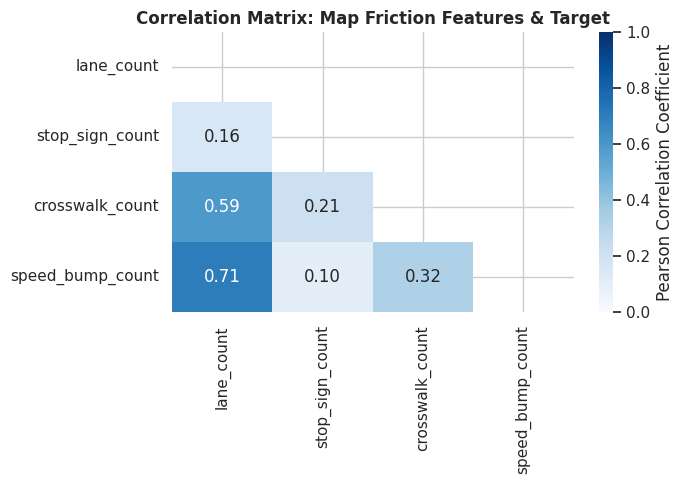


--- Variance Inflation Factors (VIF) ---


,Feature,VIF Score
0,lane_count,8.46
1,stop_sign_count,1.85
2,crosswalk_count,4.73
3,speed_bump_count,4.13



--- 6. Target Variable Class Imbalance ---
Could not find 'complex_interaction' in df_raw. Please update 'target_col' to match your column name.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 5. Map Friction Multicollinearity & Correlation Check ---
print("\n--- 5. Map Friction Multicollinearity Check ---")

# Define target column
target_col = 'complex_interaction'

# List friction features (automatically appends speed_bump_count if present in your dataframe)
friction_features = ['lane_count', 'stop_sign_count', 'crosswalk_count']
if 'speed_bump_count' in df_raw.columns:
    friction_features.append('speed_bump_count')

# Combine features + target for full correlation matrix
corr_cols = friction_features.copy()
if target_col in df_raw.columns:
    corr_cols.append(target_col)

# 1. Calculate Pearson correlation matrix
correlation_matrix = df_raw[corr_cols].corr()
print("Correlation Matrix:")
display(correlation_matrix.round(2))

# 2. Mask upper triangle for visual clarity
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 3. Plot enhanced visual heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Matrix: Map Friction Features & Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Compute Variance Inflation Factors (VIF)
print("\n--- Variance Inflation Factors (VIF) ---")
vif_df = df_raw[friction_features].dropna()

vif_data = pd.DataFrame({
    "Feature": friction_features,
    "VIF Score": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
})
display(vif_data.round(2))


# --- 6. Target Variable Class Imbalance ---
print("\n--- 6. Target Variable Class Imbalance ---")

if target_col in df_raw.columns:
    # Breakdown dataframe
    class_counts = df_raw[target_col].value_counts()
    class_balance = df_raw[target_col].value_counts(normalize=True) * 100

    imbalance_df = pd.DataFrame({
        'Scenario Count': class_counts,
        'Percentage (%)': class_balance.round(2)
    })
    print("Class Imbalance Breakdown:\n", imbalance_df)

    # Visualizing class balance with percentage annotations
    plt.figure(figsize=(6, 4.5))
    ax = sns.countplot(
        data=df_raw,
        x=target_col,
        hue=target_col,
        palette='Set2',
        legend=False
    )

    # Annotate percentage values on top of bars
    total_samples = len(df_raw[target_col].dropna())
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{100 * height / total_samples:.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

    plt.title('Target Variable: Class Imbalance Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Complex Interaction (0 = Routine, 1 = High Complexity)')
    plt.ylabel('Scenario Count')
    plt.ylim(0, max(class_counts) * 1.15)  # Add padding for labels
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find '{target_col}' in df_raw. Please update 'target_col' to match your column name.")

**Section 1: Data Cleaning & Filtering**

In [9]:
# Filter out the anomalies to create the final clean dataset for Machine Learning
df_final = pd.DataFrame(raw_extracted_scenes)
df_final = df_final[df_final['is_valid_physics'] == True] # Filter anomalies

print(f"Filter successfully applied.")
print(f"Clean scenarios ready for K-Means Clustering: {len(df_final)}")

Filter successfully applied.
Clean scenarios ready for K-Means Clustering: 6311


**Section 3: Unsupervised Risk Matrix (Target Engineering)**

In [10]:
import pandas as pd
from sklearn.cluster import KMeans

print("--- RUNNING KINEMATIC RISK CLUSTERING & FORCING TARGET OVERWRITE ---")

# 1. Isolate physics features
kinematic_features = df_final[['max_velocity_mps', 'max_deceleration']]

# 2. Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['risk_tier_numeric'] = kmeans.fit_predict(kinematic_features)

# 3. Explicitly map and OVERWRITE the target variable column
binary_mapping = {
    2: 'Standard Complexity',  # Low speed, low braking
    0: 'Standard Complexity',  # Moderate speed, low braking
    3: 'Critical Complexity',  # Moderate speed, heavy braking
    1: 'Critical Complexity'   # High speed, extreme braking
}
df_final['target_risk_matrix'] = df_final['risk_tier_numeric'].map(binary_mapping)

print("\nNew Binary Target Variable Distribution:")
print(df_final['target_risk_matrix'].value_counts(normalize=True).round(4) * 100)

--- RUNNING KINEMATIC RISK CLUSTERING & FORCING TARGET OVERWRITE ---

New Binary Target Variable Distribution:
target_risk_matrix
Standard Complexity    58.66
Critical Complexity    41.34
Name: proportion, dtype: float64


--- TARGET CLASS BALANCE SUMMARY ---


,Risk Class,Proportion,Percentage,Scenario Count
0,Standard Complexity,0.586595,58.66%,3702
1,Critical Complexity,0.413405,41.34%,2609


/tmp/ipykernel_4155/605394411.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=balance_df, x='Risk Class', y='Scenario Count', palette=['#4C72B0', '#DD8452'])


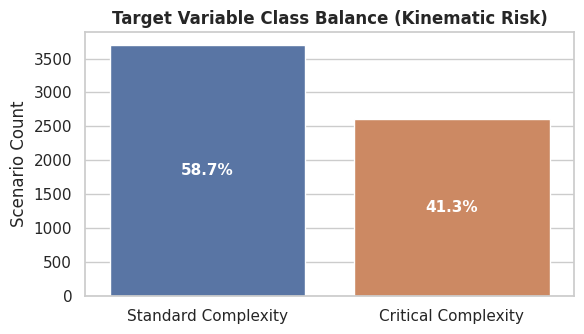

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Summary Table
balance_df = df_final['target_risk_matrix'].value_counts(normalize=True).reset_index()
balance_df.columns = ['Risk Class', 'Proportion']
balance_df['Percentage'] = (balance_df['Proportion'] * 100).round(2).astype(str) + '%'
balance_df['Scenario Count'] = df_final['target_risk_matrix'].value_counts().values

print("--- TARGET CLASS BALANCE SUMMARY ---")
display(balance_df)

# 2. Simple Class Balance Plot
plt.figure(figsize=(6, 3.5))
ax = sns.barplot(data=balance_df, x='Risk Class', y='Scenario Count', palette=['#4C72B0', '#DD8452'])
plt.title('Target Variable Class Balance (Kinematic Risk)', fontsize=12, fontweight='bold')
plt.ylabel('Scenario Count')
plt.xlabel('')

# Annotate percentages on top of bars
for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_final)) * 100
    ax.annotate(f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()